In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

In [ ]:
import equinox as eqx
import esm  # pip install fair-esm==2.0.0
import esm2quinox
import jax.random as jrandom
import optax  # pip install optax
from dataset.dataset import initialize_datasets, Dataset_PEPBI
from functions.model import AFF_PREDICTOR,stripped_PREDICTOR, combined_PREDICTOR, fine_tune_PREDICTOR
from functions.training import train_model, eval_step, train_model_validation, train_model_validation_combined, train_model_fine_tuning
import jax.numpy as jnp
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import jax.random as jr
import jax
import pandas as pd
from torch.utils.data import DataLoader, RandomSampler, random_split
import jax.tree_util as jtu
from functions import plots

In [7]:
#base_path = '/home/kunzj'
base_path = '/home/jkunz/master_uni_hd/internship_amsterdam'

pepbi dataset

In [ ]:
# data_train = Dataset_PEPBI(
#     columns=["Prot_Seq", "Pept_Seq", "Energy"],
#     data_path=f"{base_path}/BindCraft_uva_internship/data/pepbi/min_max_scaled/train_data_pepbi.csv",
#     transform=esm2quinox.tokenise
# )
# train_loader = DataLoader(data_train,batch_size=20)
# sns.kdeplot(data_train.aff_Vals)val_losses = [x.item() for x in val_losses]

# data_test = Dataset_PEPBI(
#     columns=["Prot_Seq", "Pept_Seq", "Energy"],
#     data_path=f"{base_path}/BindCraft_uva_internship/data/pepbi/min_max_scaled/test_data_pepbi.csv",
#     transform=esm2quinox.tokenise
# )
# test_loader = DataLoader(data_test,batch_size=1)
# test_key_init = jrandom.PRNGKey(1)

mmpbsa dataset - cosine similarity

In [17]:
data_mmpbsa_all = Dataset_PEPBI(
    columns=["seq_prot", "seq_pept", "final_score"],
    data_path=f"{base_path}/BindCraft_uva_internship/data/mmpbsa/finished_data_cosine_sim.csv",
    transform=esm2quinox.tokenise
)
data_mmpbsa_train = Dataset_PEPBI(
    columns=["seq_prot", "seq_pept", "final_score"],
    data_path=f"{base_path}/BindCraft_uva_internship/data/mmpbsa/split/finished_data_cosine_sim_train.csv",
    transform=esm2quinox.tokenise
)
data_mmpbsa_validation = Dataset_PEPBI(
    columns=["seq_prot", "seq_pept", "final_score"],
    data_path=f"{base_path}/BindCraft_uva_internship/data/mmpbsa/split/finished_data_cosine_sim_validation.csv",
    transform=esm2quinox.tokenise
)

data_mmpbsa_train_three_split= Dataset_PEPBI(
    columns=["seq_prot", "seq_pept", "final_score"],
    data_path=f"{base_path}/BindCraft_uva_internship/data/mmpbsa/three_way_split/finished_data_cosine_sim_train.csv",
    transform=esm2quinox.tokenise
)
data_mmpbsa_validation_three_split= Dataset_PEPBI(
    columns=["seq_prot", "seq_pept", "final_score"],
    data_path=f"{base_path}/BindCraft_uva_internship/data/mmpbsa/three_way_split/finished_data_cosine_sim_validation.csv",
    transform=esm2quinox.tokenise
)
data_mmpbsa_test_three_split= Dataset_PEPBI(
    columns=["seq_prot", "seq_pept", "final_score"],
    data_path=f"{base_path}/BindCraft_uva_internship/data/mmpbsa/three_way_split/finished_data_cosine_sim_test.csv",
    transform=esm2quinox.tokenise
)


mmpbsa_all_data_loader = DataLoader(data_mmpbsa_all,batch_size=1)
mmpbsa_train_data_loader = DataLoader(data_mmpbsa_train,batch_size=3)
mmpbsa_validation_data_loader = DataLoader(data_mmpbsa_validation,batch_size=1)


mmpbsa_train_data_loader_three_split = DataLoader(data_mmpbsa_train_three_split,batch_size=3)
mmpbsa_validation_data_loader_three_split = DataLoader(data_mmpbsa_validation_three_split,batch_size=1)
mmpbsa_test_data_loader_three_split = DataLoader(data_mmpbsa_test_three_split,batch_size=1)

<Axes: ylabel='Density'>

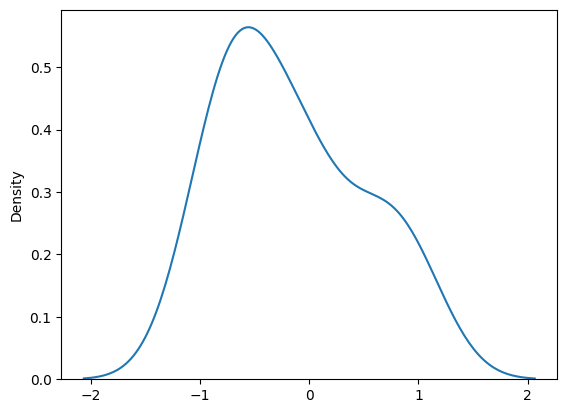

In [40]:
sns.kdeplot(data_mmpbsa_validation.aff_Vals)

<Axes: ylabel='Count'>

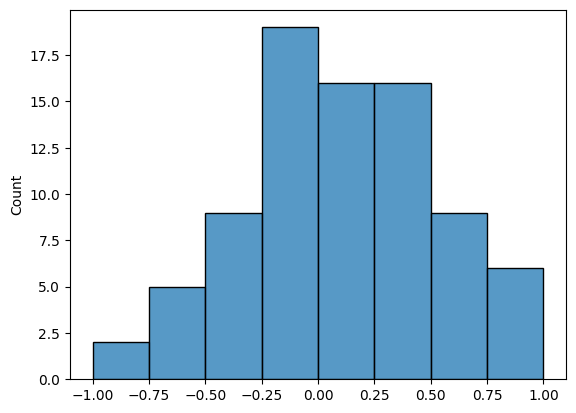

In [36]:
sns.histplot(data_mmpbsa_train.aff_Vals)

<Axes: ylabel='Count'>

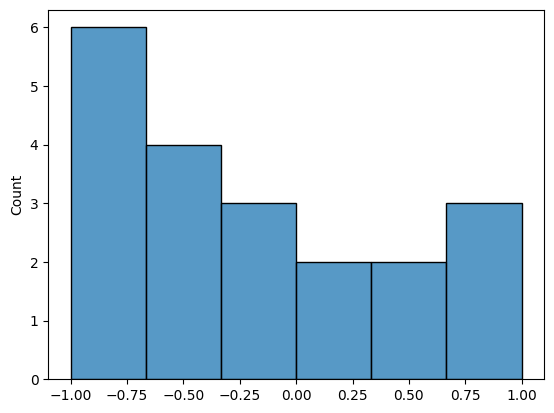

In [35]:
sns.histplot(data_mmpbsa_validation.aff_Vals)

<Axes: ylabel='Count'>

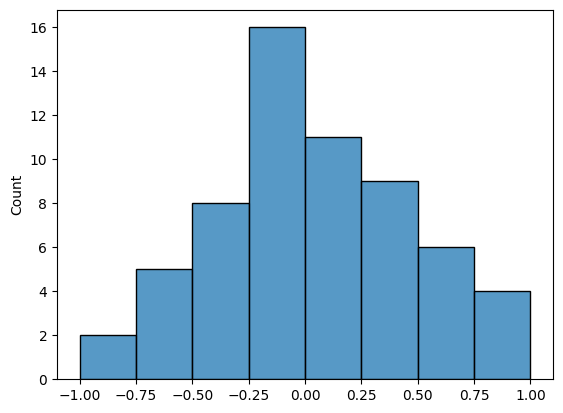

In [19]:
sns.histplot(data_mmpbsa_train_three_split.aff_Vals)

<Axes: ylabel='Count'>

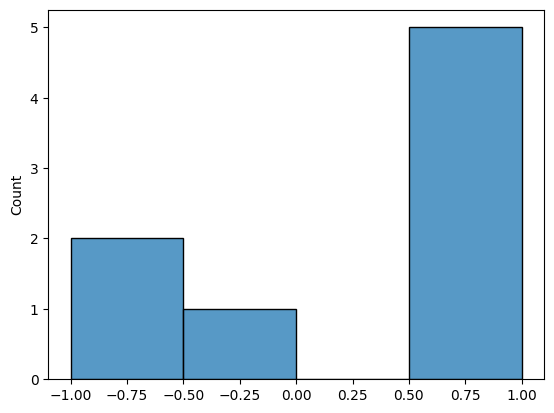

In [20]:
sns.histplot(data_mmpbsa_validation_three_split.aff_Vals)

<Axes: ylabel='Count'>

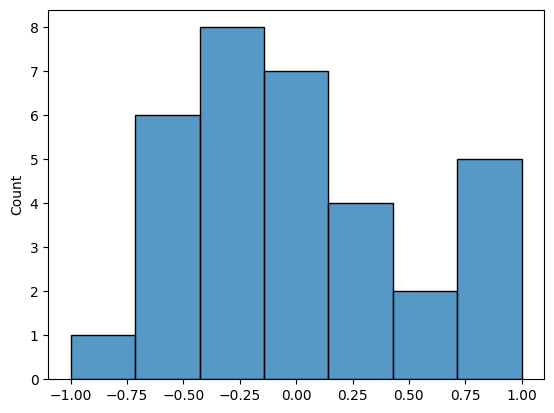

In [21]:
sns.histplot(data_mmpbsa_test_three_split.aff_Vals)

weird dataset

In [ ]:
# data_train = Dataset_PEPBI(
#     columns=["Prot_Seq", "Pept_Seq", "Energy"],
#     data_path=f"{base_path}/BindCraft_uva_internship/data/weird_dataset/train.csv",
#     transform=esm2quinox.tokenise,
# )
# train_loader = DataLoader(data_train, batch_size=20)


# data_validation = Dataset_PEPBI(
#     columns=["Prot_Seq", "Pept_Seq", "Energy"],
#     data_path=f"{base_path}/BindCraft_uva_internship/data/weird_dataset/validation.csv",
#     transform=esm2quinox.tokenise,
# )
# validation_loader = DataLoader(data_validation, batch_size=1)

# data_test = Dataset_PEPBI(
#     columns=["Prot_Seq", "Pept_Seq", "Energy"],
#     data_path=f"{base_path}/BindCraft_uva_internship/data/weird_dataset/test.csv",
#     transform=esm2quinox.tokenise,
# )
# test_loader = DataLoader(data_test, batch_size=1)

# test_key_init = jrandom.PRNGKey(1)

weird dataset - cosine similarity


In [22]:
data_train = Dataset_PEPBI(
    columns=["Prot_Seq", "Pept_Seq", "Energy"],
    data_path=f"{base_path}/BindCraft_uva_internship/data/ppi_affinity_dataset/cosine_sim_scaled/train.csv",
    transform=esm2quinox.tokenise,
)
train_loader = DataLoader(data_train, batch_size=20)



data_validation = Dataset_PEPBI(
    columns=["Prot_Seq", "Pept_Seq", "Energy"],
    data_path=f"{base_path}/BindCraft_uva_internship/data/ppi_affinity_dataset/cosine_sim_scaled/validation.csv",
    transform=esm2quinox.tokenise,
)
validation_loader = DataLoader(data_validation, batch_size=1)

data_test = Dataset_PEPBI(
    columns=["Prot_Seq", "Pept_Seq", "Energy"],
    data_path=f"{base_path}/BindCraft_uva_internship/data/ppi_affinity_dataset/cosine_sim_scaled/test.csv",
    transform=esm2quinox.tokenise,
)
test_loader = DataLoader(data_test, batch_size=1)

test_key_init = jrandom.PRNGKey(1)

<Axes: ylabel='Count'>

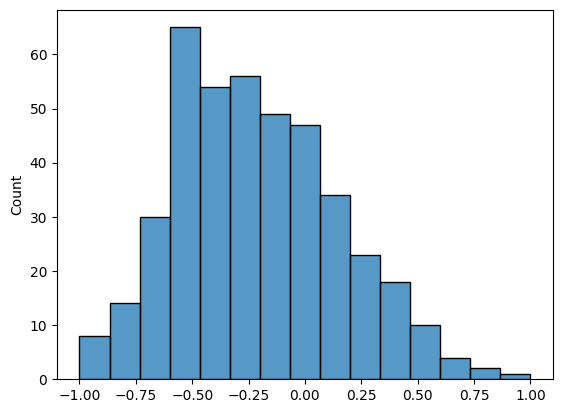

In [25]:
sns.histplot(data_train.aff_Vals)

<Axes: ylabel='Count'>

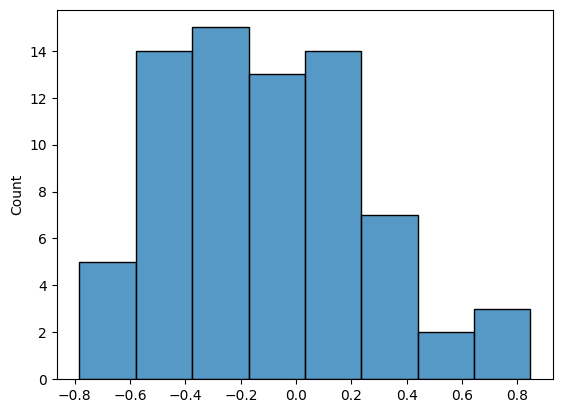

In [26]:
sns.histplot(data_validation.aff_Vals)

model initilialization

In [27]:
# generating keys
model_key, call_key = jr.split(jrandom.PRNGKey(0), 2)

# initializing models
torch_model, _ = esm.pretrained.esm2_t30_150M_UR50D()
model_esm2 = esm2quinox.from_torch(torch_model)
model_aff, model_state = eqx.nn.make_with_state(stripped_PREDICTOR)(
    model=model_esm2, key=model_key
)

# initializing optimizer
optim = optax.adam(learning_rate=0.001)
opt_state = optim.init(eqx.filter(model_aff, eqx.is_inexact_array))


Downloading: "https://dl.fbaipublicfiles.com/fair-esm/models/esm2_t30_150M_UR50D.pt" to /home/jkunz/.cache/torch/hub/checkpoints/esm2_t30_150M_UR50D.pt
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/regression/esm2_t30_150M_UR50D-contact-regression.pt" to /home/jkunz/.cache/torch/hub/checkpoints/esm2_t30_150M_UR50D-contact-regression.pt


In [ ]:
# eqx.tree_serialise_leaves('/home/jkunz/master_uni_hd/internship_amsterdam/carbon/BindCraft_uva_internship/notebooks/test.txt',model_aff)

In [ ]:
target_str =['QPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELALDPVPQDASTKKLSECLKRIGDELDSNMELQRMIAAVDTDSPREVFFRVAADMFSDGNFNWGRVVALFYFASKLVLKALCTKVPELIRTIMGWTLDFLRERLLGWIQDQGGWDGLLSYFG']
x_prot = esm2quinox.tokenise(target_str)
test_key = model_key[0]

train model

train model with validation

In [28]:
best_model, model_state, train_losses, val_losses = train_model_validation(
    training_DataLoader=train_loader,
    validation_Dataloader=validation_loader,
    max_epochs=3,
    model_aff=model_aff,
    model_state=model_state,
    opt_state=opt_state,
    optim=optim,
    key=call_key,
)

Epochs:   0%|          | 0/3 [00:00<?, ?it/s]

KeyboardInterrupt: 

additional training with mmpbsa data

In [ ]:
best_model, model_state, train_losses, val_losses = train_model_validation(
    training_DataLoader=mmpbsa_train_data_loader_three_split,
    validation_Dataloader=mmpbsa_validation_data_loader_three_split,
    max_epochs=100,
    model_aff=model_aff,
    model_state=model_state,
    opt_state=opt_state,
    optim=optim,
    key=call_key,
)

test - ppbi data

In [9]:
test_key_init = jrandom.PRNGKey(1)
inference_model = eqx.nn.inference_mode(best_model)
inference_model = eqx.Partial(inference_model, state=model_state)

test_loss_list = []
pred_y_list = []
y_val_list = []

for entry, (x_prot, x_pept, y_val) in enumerate(test_loader):
    x_prot, x_pept, y_val = jnp.array(x_prot), jnp.array(x_pept), jnp.array(y_val)
    test_key = jr.split(test_key_init, x_pept.shape[0])
    test_loss, pred_y = eval_step(inference_model, x_prot, x_pept, y_val, test_key)
    test_loss_list.append(test_loss.item())
    pred_y_list.append(pred_y.item())
    y_val_list.append(y_val.item())
    print(
        f"[Entry {entry + 1}] , Test Loss: {test_loss:.3f}, Predicted Y: {pred_y.item():.3f}, , True Y: {y_val.item():.3f}"
    )


[Entry 1] , Test Loss: 0.000, Predicted Y: 0.317, , True Y: 0.315
[Entry 2] , Test Loss: 0.001, Predicted Y: 0.666, , True Y: 0.641
[Entry 3] , Test Loss: 0.000, Predicted Y: 0.457, , True Y: 0.452
[Entry 4] , Test Loss: 0.152, Predicted Y: 0.610, , True Y: 0.220
[Entry 5] , Test Loss: 0.001, Predicted Y: 0.172, , True Y: 0.207
[Entry 6] , Test Loss: 0.003, Predicted Y: 0.197, , True Y: 0.254
[Entry 7] , Test Loss: 0.146, Predicted Y: 0.145, , True Y: -0.237
[Entry 8] , Test Loss: 0.055, Predicted Y: 0.315, , True Y: 0.080
[Entry 9] , Test Loss: 0.213, Predicted Y: 0.124, , True Y: 0.585
[Entry 10] , Test Loss: 0.013, Predicted Y: 0.134, , True Y: 0.018
[Entry 11] , Test Loss: 0.086, Predicted Y: 0.404, , True Y: 0.111
[Entry 12] , Test Loss: 0.040, Predicted Y: 0.238, , True Y: 0.438
[Entry 13] , Test Loss: 0.116, Predicted Y: 0.168, , True Y: 0.510
[Entry 14] , Test Loss: 0.182, Predicted Y: 0.248, , True Y: -0.178
[Entry 15] , Test Loss: 0.177, Predicted Y: 0.187, , True Y: -0.234
[

test - mmpbsa data

In [ ]:
test_key_init = jrandom.PRNGKey(1)
inference_model = eqx.nn.inference_mode(best_model)
inference_model = eqx.Partial(inference_model, state=model_state)

test_loss_list = []
pred_y_list = []
y_val_list = []

for entry, (x_prot, x_pept, y_val) in enumerate(mmpbsa_all_data_loader):
    x_prot, x_pept, y_val = jnp.array(x_prot), jnp.array(x_pept), jnp.array(y_val)
    test_key = jr.split(test_key_init, x_pept.shape[0])
    test_loss, pred_y = eval_step(inference_model, x_prot, x_pept, y_val, test_key)
    test_loss_list.append(test_loss.item())
    pred_y_list.append(pred_y.item())
    y_val_list.append(y_val.item())
    print(
        f"[Entry {entry + 1}] , Test Loss: {test_loss:.3f}, Predicted Y: {pred_y.item():.3f}, , True Y: {y_val.item():.3f}"
    )


In [ ]:
test_key_init = jrandom.PRNGKey(1)
inference_model = eqx.nn.inference_mode(best_model)
inference_model = eqx.Partial(inference_model, state=model_state)

test_loss_list = []
pred_y_list = []
y_val_list = []

for entry, (x_prot, x_pept, y_val) in enumerate(mmpbsa_test_data_loader_three_split):
    x_prot, x_pept, y_val = jnp.array(x_prot), jnp.array(x_pept), jnp.array(y_val)
    test_key = jr.split(test_key_init, x_pept.shape[0])
    test_loss, pred_y = eval_step(inference_model, x_prot, x_pept, y_val, test_key)
    test_loss_list.append(test_loss.item())
    pred_y_list.append(pred_y.item())
    y_val_list.append(y_val.item())
    print(
        f"[Entry {entry + 1}] , Test Loss: {test_loss:.3f}, Predicted Y: {pred_y.item():.3f}, , True Y: {y_val.item():.3f}"
    )


<Axes: >

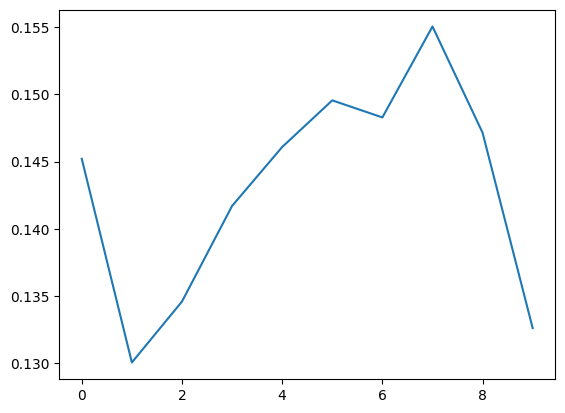

In [10]:

sns.lineplot(val_losses)

<Axes: >

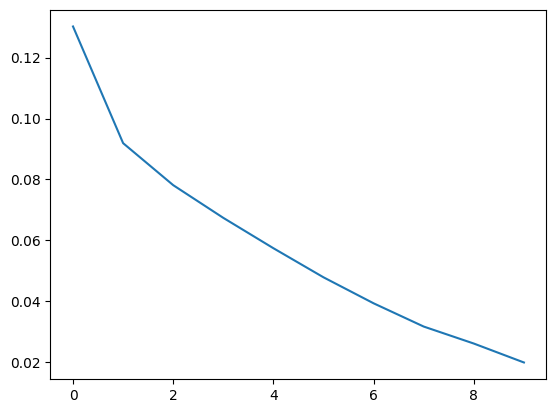

In [11]:
sns.lineplot(train_losses)

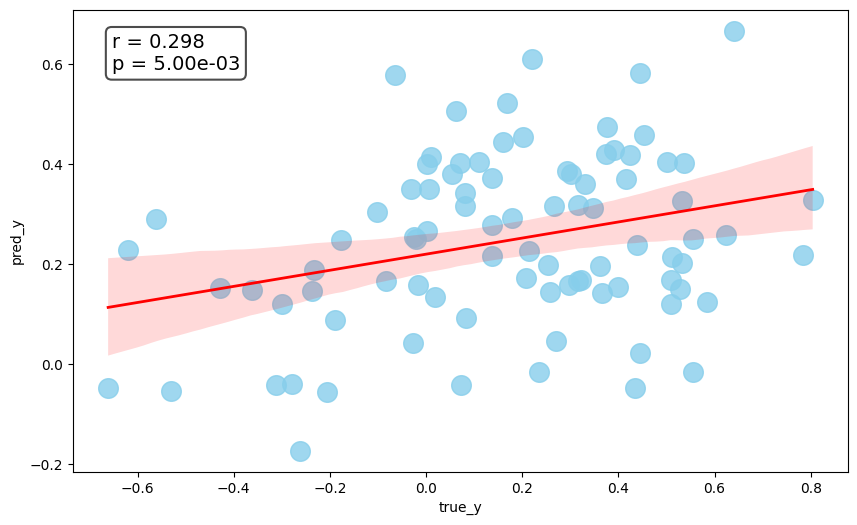

In [12]:
plots.linear_corr_plot(y_val_list,pred_y_list,'true_y','pred_y')

<Axes: >

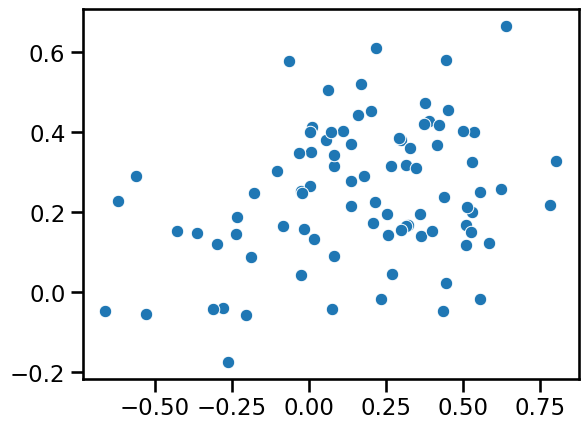

In [13]:
sns.scatterplot(x=y_val_list,y=pred_y_list)

In [ ]:
sns.lineplot(test_loss_list)

In [ ]:
sns.kdeplot(test_loss_list)

In [ ]:
eqx.tree_serialise_leaves('../params/model_inference.eqx',inference_model)

### train on three way mmpbsa dataset

In [ ]:
# generating keys
model_key, call_key = jr.split(jrandom.PRNGKey(0), 2)

# initializing models
torch_model, _ = esm.pretrained.esm2_t30_150M_UR50D()
model_esm2 = esm2quinox.from_torch(torch_model)
model_aff, model_state = eqx.nn.make_with_state(stripped_PREDICTOR)(
    model=model_esm2, key=model_key
)

# initializing optimizer
optim = optax.adam(learning_rate=0.001)
opt_state = optim.init(eqx.filter(model_aff, eqx.is_inexact_array))

In [ ]:
best_model_first, model_state_first, train_losses_first, val_losses_first = train_model_validation(
    training_DataLoader=mmpbsa_train_data_loader_three_split,
    validation_Dataloader=mmpbsa_validation_data_loader_three_split,
    max_epochs=3,
    model_aff=model_aff,
    model_state=model_state,
    opt_state=opt_state,
    optim=optim,
    key=call_key,
)

### train easy model with both dataset

In [ ]:
# generating keys
model_key, call_key = jr.split(jrandom.PRNGKey(0), 2)

# initializing models
torch_model, _ = esm.pretrained.esm2_t30_150M_UR50D()
model_esm2 = esm2quinox.from_torch(torch_model)
model_aff, model_state = eqx.nn.make_with_state(stripped_PREDICTOR)(
    model=model_esm2, key=model_key
)

# initializing optimizer
optim = optax.adam(learning_rate=0.001)
opt_state = optim.init(eqx.filter(model_aff, eqx.is_inexact_array))

In [ ]:
best_model_first, model_state_first, train_losses_first, val_losses_first = train_model_validation(
    training_DataLoader=train_loader,
    validation_Dataloader=validation_loader,
    max_epochs=3,
    model_aff=model_aff,
    model_state=model_state,
    opt_state=opt_state,
    optim=optim,
    key=call_key,
)

In [ ]:
# initializing optimizer
optim = optax.adam(learning_rate=0.001)
opt_state = optim.init(eqx.filter(best_model_first, eqx.is_inexact_array))

best_model, model_state, train_losses_second, val_losses_second = train_model_validation(
    training_DataLoader=mmpbsa_train_data_loader,
    validation_Dataloader=mmpbsa_validation_data_loader,
    max_epochs=3,
    model_aff=best_model_first,
    model_state=model_state_first,
    opt_state=opt_state,
    optim=optim,
    key=call_key,
)

### training real with additional layer

In [ ]:
# generating keys
model_key, call_key = jr.split(jrandom.PRNGKey(0), 2)

# initializing models
torch_model, _ = esm.pretrained.esm2_t30_150M_UR50D()
model_esm2 = esm2quinox.from_torch(torch_model)
model_aff, model_state = eqx.nn.make_with_state(fine_tune_PREDICTOR)(
    model=model_esm2, key=model_key
)

# initializing optimizer
optim = optax.adam(learning_rate=0.001)
opt_state = optim.init(eqx.filter(model_aff, eqx.is_inexact_array))

In [ ]:
best_model_first, model_state_first, train_losses_first, val_losses_first = train_model_fine_tuning(
    training_DataLoader=train_loader,
    validation_Dataloader=validation_loader,
    max_epochs=3,
    model_aff=model_aff,
    model_state=model_state,
    opt_state=opt_state,
    optim=optim,
    key=call_key,
)

In [ ]:
# initializing optimizer
optim = optax.adam(learning_rate=0.001)
opt_state = optim.init(eqx.filter(best_model_first, eqx.is_inexact_array))

best_model, model_state, train_losses_second, val_losses_second = train_model_validation(
    training_DataLoader=mmpbsa_train_data_loader,
    validation_Dataloader=mmpbsa_validation_data_loader,
    max_epochs=3,
    model_aff=best_model_first,
    model_state=model_state_first,
    opt_state=opt_state,
    optim=optim,
    key=call_key,
)